In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import torch
import sys
from scipy import stats

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/')
from simulate_ALBF_calibration_eval import ALBFCalibrationAnalysis

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/')
from estimate_bayesian_fdr import *

In [2]:
# Main path set up
main_path="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/0203"

# Choose which simulation directory to analyze 
dir_analyze="analysis_20250203_104134_PropNeg_0.5_K_2_NoWaypoints_Prior_NoGlobalPrior_NumEpochs_300_ConcPrior_inf_Inits_2_NoCellType_Random_58263"

# Set up the path to the simulation directory
sim_dir=os.path.join(main_path,dir_analyze)

# Print the names of the files in the simulation directory
files = os.listdir(sim_dir)
print(files)

['clustermap.png', 'losses.png', 'random_init_25830_loss_curve.png', 'assignment_correlations.png', 'est_deltapsi_vs_difference.png', 'pi_barplot.png', 'nmf_clustermap.png', 'nmf_umap.png.pdf', 'ALBF_scores.csv', 'random_init_64263_loss_curve.png', 'albf_vs_difference.png', 'cell_type_psi_df.csv', 'final_results.csv', 'ALBF_report.txt', 'umap.png.pdf', 'roc_curve.png', 'est_deltapsi_vs_difference.pdf', 'parameters.json', 'precision_recall_curve.png', 'analysis_report.txt', 'precision_recall_curve.pdf', 'ALBF_score_distribution.png']


In [3]:
# Original PSI_df from simulation
PSI_df = pd.read_csv(os.path.join(sim_dir, "cell_type_psi_df.csv"))

In [4]:
PSI_df

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
0,0,0.228267,0.228267,0,chr10_100080130_100080856_+,negative,35178,0.000000,negative
1,1,0.543466,0.543466,1,chr10_100080130_100087346_+,negative,35178,0.000000,negative
2,2,0.228267,0.228267,2,chr10_100080940_100087346_+,negative,35178,0.000000,negative
3,0,0.166983,0.166983,3,chr10_100478022_100485050_-,negative,37286,0.000000,negative
4,1,0.666034,0.666034,4,chr10_100478022_100487161_-,negative,37286,0.000000,negative
...,...,...,...,...,...,...,...,...,...
15889,1,0.791347,0.791347,15889,chrY_898115_899427_+,negative,62094,0.000000,negative
15890,2,0.104326,0.104326,15890,chrY_898627_899427_+,negative,62094,0.000000,negative
15891,0,0.458049,0.130319,15891,chrY_900613_910447_+,positive,62095,0.327730,positive
15892,1,0.083901,0.739362,15892,chrY_910586_910656_+,positive,62095,0.655461,positive


In [5]:
PSI_df[PSI_df["true_label"] == "negative"]

,index,0,1,junction_id_index,junction_id,sample_label,Cluster,difference,true_label
0,0,0.228267,0.228267,0,chr10_100080130_100080856_+,negative,35178,0.0,negative
1,1,0.543466,0.543466,1,chr10_100080130_100087346_+,negative,35178,0.0,negative
2,2,0.228267,0.228267,2,chr10_100080940_100087346_+,negative,35178,0.0,negative
3,0,0.166983,0.166983,3,chr10_100478022_100485050_-,negative,37286,0.0,negative
4,1,0.666034,0.666034,4,chr10_100478022_100487161_-,negative,37286,0.0,negative
...,...,...,...,...,...,...,...,...,...
15886,1,0.994521,0.994521,15886,chrY_1280439_1284321_-,negative,62124,0.0,negative
15887,2,0.002739,0.002739,15887,chrY_1282948_1284321_-,negative,62124,0.0,negative
15888,0,0.104326,0.104326,15888,chrY_898115_898549_+,negative,62094,0.0,negative
15889,1,0.791347,0.791347,15889,chrY_898115_899427_+,negative,62094,0.0,negative


In [6]:
PSI_df.sample_label.value_counts()

sample_label
negative    7947
positive    7947
Name: count, dtype: int64

In [7]:
# let's load the final_results.csv file 
albf_scores = pd.read_csv(os.path.join(sim_dir, "ALBF_scores.csv"))
# rename the first two columns to be sim_psi_1 and sim_psi_2
albf_scores = albf_scores.rename(columns={"0": "latent_psi_1", "1": "latent_psi_2"})
albf_scores.head()

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
0,0.228180,0.231305,0,0.004780,0.0,negative,35178,0,0.003126,0
1,0.547275,0.539937,1,0.011352,0.0,negative,35178,0,0.007338,0
2,0.227712,0.226713,2,0.000107,0.0,negative,35178,0,0.000999,0
3,0.176503,0.171861,3,0.004192,0.0,negative,37286,0,0.004642,0
4,0.667641,0.660762,4,0.004796,0.0,negative,37286,0,0.006879,0


In [8]:
# How many ALBF values less than 1 
print("Number of ALBF values less than 1: ", len(albf_scores[albf_scores["ALBF"] < 1]))
# How many ALBF values greater than 1
print("Number of ALBF values greater than 1: ", len(albf_scores[albf_scores["ALBF"] > 1]))
# How many ALBF values less than 0 
print("Number of ALBF values less than 0: ", len(albf_scores[albf_scores["ALBF"] < 0]))

Number of ALBF values less than 1:  8648
Number of ALBF values greater than 1:  7246
Number of ALBF values less than 0:  7


In [9]:
def analyze_null_albf(df):
    """
    Analyze ALBF distribution for negative junctions
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'ALBF' and 'true_label' columns
    
    Returns
    -------
    dict
        Dictionary containing null distribution parameters
    """
    # Get ALBF values for negative junctions
    null_albf = df[df['true_label'] == 'negative']['ALBF']
    
    # Fit normal distribution to null ALBFs
    mu, std = stats.norm.fit(null_albf)
    
    # Test for normality
    _, norm_pval = stats.normaltest(null_albf)
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    
    # Plot histogram of null ALBF values
    sns.histplot(null_albf, bins=30, color='blue', alpha=0.5, label='Observed')
    
    # Plot fitted normal distribution
    x = np.linspace(null_albf.min(), null_albf.max(), 100)
    plt.plot(x, stats.norm.pdf(x, mu, std) * len(null_albf) * (null_albf.max() - null_albf.min()) / 30,
             'r-', label='Fitted Normal')
    
    plt.title(f'Distribution of ALBF Values for Negative Junctions\nμ={mu:.2f}, σ={std:.2f}, p={norm_pval:.2e}')
    plt.xlabel('ALBF')
    plt.ylabel('Count')
    plt.legend()
    
    # Calculate percentiles for potential thresholds
    percentiles = [90, 95, 99]
    thresholds = np.percentile(null_albf, percentiles)
    
    return {
        'mu': mu,
        'std': std,
        'normality_pvalue': norm_pval,
        'thresholds': dict(zip(percentiles, thresholds))
    }

In [10]:
albf_scores.sort_values(by=["true_label", "ALBF"], ascending=[True, False], inplace=True)
albf_scores

,latent_psi_1,latent_psi_2,junction_id_index,ALBF,difference,true_label,Cluster,true_label_binary,delta_est,predicted_label
5607,0.001428,0.010991,5607,1.593567,0.000000,negative,57100,0,0.009562,1
7366,0.001113,0.006267,7366,1.149006,0.000000,negative,2018,0,0.005155,1
610,0.005226,0.000710,610,1.122891,0.000000,negative,35643,0,0.004517,1
11817,0.000614,0.006129,11817,1.122295,0.000000,negative,21040,0,0.005515,1
3937,0.986706,0.998381,3937,1.086508,0.000000,negative,50403,0,0.011675,1
...,...,...,...,...,...,...,...,...,...,...
1604,0.368465,0.367282,1604,0.000582,0.001182,positive,39606,1,0.001184,0
14585,0.308389,0.311112,14585,0.000568,0.000884,positive,32545,1,0.002723,0
12543,0.246618,0.248609,12543,0.000465,0.001962,positive,27224,1,0.001990,0
11940,0.385944,0.388237,11940,0.000187,0.011783,positive,22373,1,0.002293,0


In [11]:
# get range of ALBF scores
albf_scores["ALBF"].min(), albf_scores["ALBF"].max()

(-0.0004272461, 1089.025)

{'mu': 0.01880739183458527,
 'std': 0.05841469083545209,
 'normality_pvalue': 0.0,
 'thresholds': {90: 0.03666768000000002,
  95: 0.06579151099999998,
  99: 0.24607070879999995}}

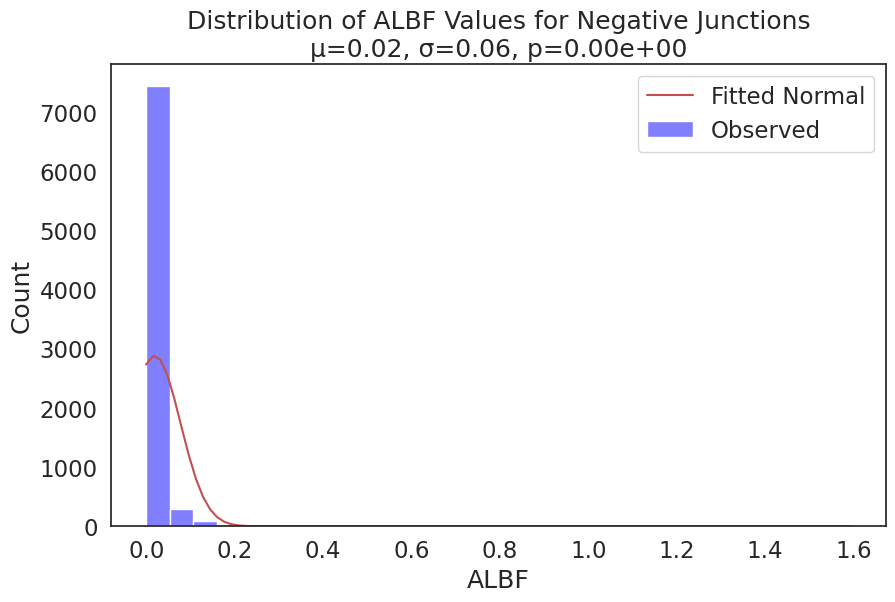

In [12]:
analyze_null_albf(albf_scores)

In [13]:
perc5=0.06579151099999998
perc1=0.24607070879999995

albf_scores[albf_scores["ALBF"] > perc5]["true_label"].value_counts(), albf_scores[albf_scores["ALBF"] > perc1]["true_label"].value_counts()

(true_label
 positive    7780
 negative     398
 Name: count, dtype: int64,
 true_label
 positive    7623
 negative      80
 Name: count, dtype: int64)

In [14]:
(7780/(398+7780), 398/(398+7780)), (7623/(80+7623), 80/(80+7623))

((0.9513328442161898, 0.04866715578381022),
 (0.9896144359340516, 0.010385564065948332))

In [15]:
albf_scores["sigmoid_ALBF"] = 1 / (1 + np.exp(-albf_scores["ALBF"]))
albf_scores["sigmoid_ALBF"].min(), albf_scores["sigmoid_ALBF"].max()

(0.4998931884766248, 1.0)

In [26]:
em = EMDifferentialSplicing(albf_scores["ALBF"], initial_p=0.1, max_iter=200)
results = em.fit()
threshold = 0.95 

Initial Statistics:
Original ALBF range: [-0.00, 1089.03]
Log ALBF range: [-0.00, 6.99]
Log ALBF median: 0.10
Scaled range: [-0.10, 6.89]
b_j range: [0.4738, 0.9990]
b_j detailed distribution (0.0-1.0 in 0.1 steps): [8183  232  192  190  186  284  411  742 1531 3943]

Iteration 1:
p: 0.348822
log likelihood: -12148.219626
q_s1 range: [0.090943, 0.990917]
q_s1 detailed distribution (0.0-1.0 in 0.1 steps): [8741  410  469  549  694  763  930 1146 1351  841]

Iteration 2:
p: 0.579966
log likelihood: -8354.574526
q_s1 range: [0.325376, 0.998102]
q_s1 detailed distribution (0.0-1.0 in 0.1 steps): [8277  278  218  200  263  371  519  938 1672 3158]

Iteration 3:
p: 0.735994
log likelihood: -7443.291067
q_s1 range: [0.554206, 0.999263]
q_s1 detailed distribution (0.0-1.0 in 0.1 steps): [8135  234  188  182  163  242  385  618 1465 4282]

Iteration 4:
p: 0.834945
log likelihood: -7149.348522
q_s1 range: [0.715102, 0.999635]
q_s1 detailed distribution (0.0-1.0 in 0.1 steps): [8060  226  177  15

In [17]:
albf_scores["posterior_probs"] = results["posterior_probs"]
threshold = 0.95 # for 5% FDR 
albf_scores["significant"] = False 
albf_scores["significant"] = albf_scores["posterior_probs"] >= threshold
albf_scores["significant"].value_counts()

significant
False    8780
True     7114
Name: count, dtype: int64

In [18]:
albf_scores[["ALBF", "true_label", "posterior_probs", "significant"]].head()

,ALBF,true_label,posterior_probs,significant
5607,1.593567,negative,0.954598,True
7366,1.149006,negative,0.945716,False
610,1.122891,negative,0.945084,False
11817,1.122295,negative,0.945070,False
3937,1.086508,negative,0.944180,False


In [19]:
# how many positives are significant
tp = albf_scores[(albf_scores["true_label"] == "positive") & (albf_scores["significant"])].shape[0]
# how many negatives are significant
fp = albf_scores[(albf_scores["true_label"] == "negative") & (albf_scores["significant"])].shape[0]
# how many positives are not significant
fn = albf_scores[(albf_scores["true_label"] == "positive") & (~albf_scores["significant"])].shape[0]
# how many negatives are not significant
tn = albf_scores[(albf_scores["true_label"] == "negative") & (~albf_scores["significant"])].shape[0]

tp, fp, fn, tn

(7113, 1, 834, 7946)

<Axes: xlabel='posterior_probs', ylabel='Count'>

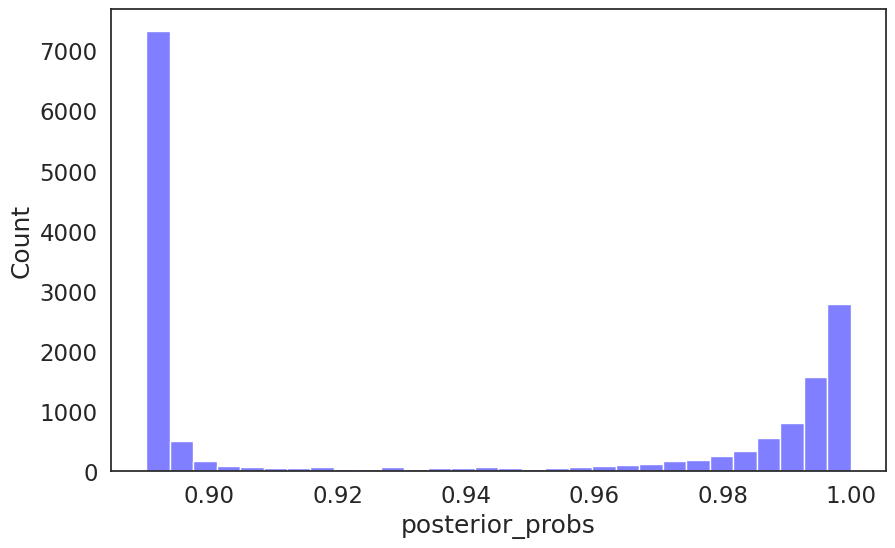

In [20]:
# make histogram of posterior probabilities
plt.figure(figsize=(10, 6))
sns.histplot(albf_scores["posterior_probs"], bins=30, color='blue', alpha=0.5)

<Axes: xlabel='ALBF', ylabel='posterior_probs'>

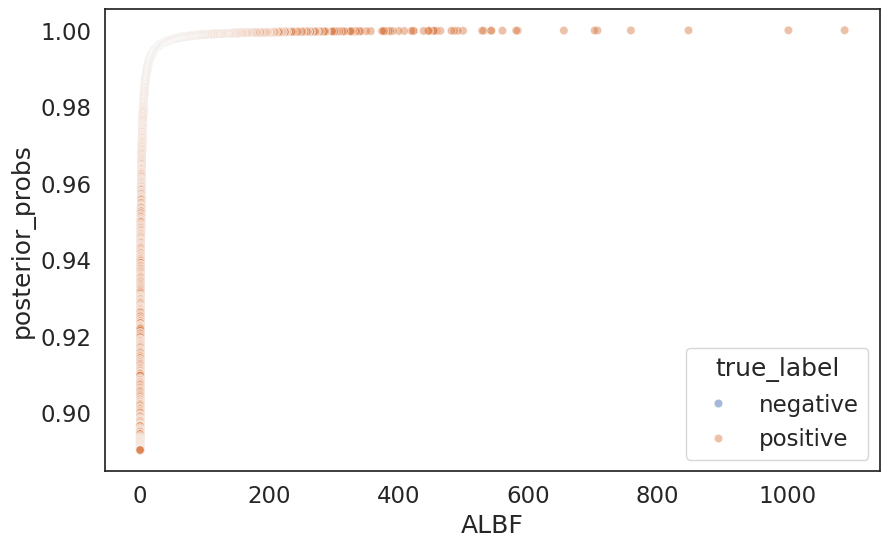

In [21]:
# let's plot difference column vs ALBF column for positive junctions under true_label
plt.figure(figsize=(10, 6))
sns.scatterplot(albf_scores, x='ALBF', y='posterior_probs', alpha=0.5, hue='true_label')

<Axes: xlabel='difference', ylabel='delta_est'>

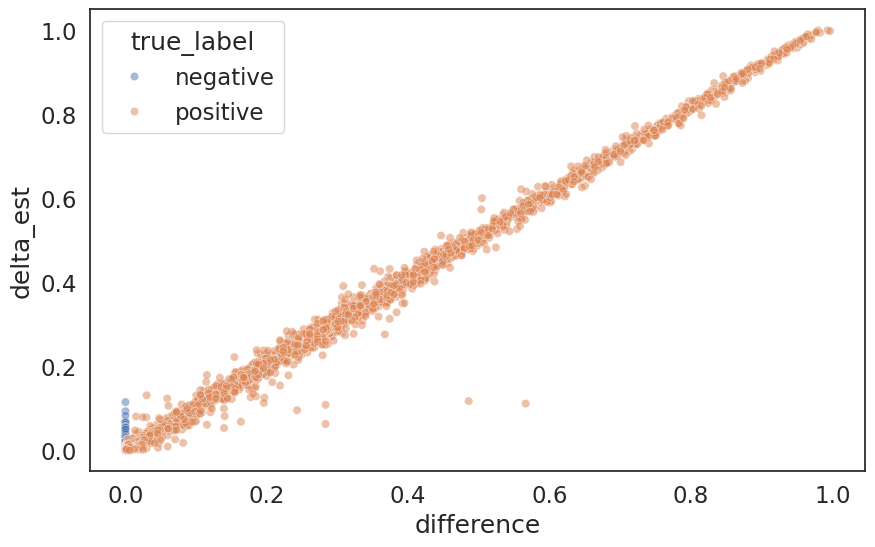

In [22]:
# let's plot difference column vs ALBF column for positive junctions under true_label
plt.figure(figsize=(10, 6))
sns.scatterplot(albf_scores, x='difference', y='delta_est', alpha=0.5, hue='true_label')

<Axes: xlabel='difference', ylabel='ALBF'>

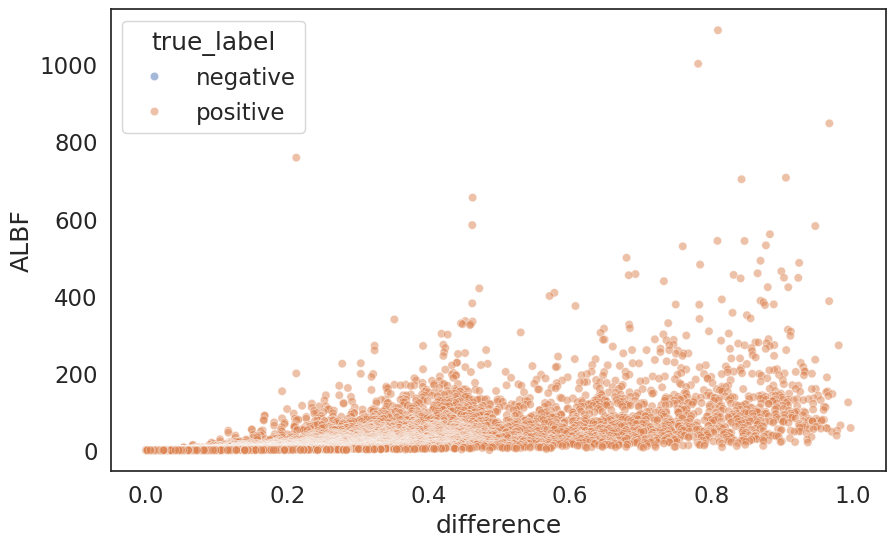

In [23]:
# let's plot difference column vs ALBF column for positive junctions under true_label
plt.figure(figsize=(10, 6))
sns.scatterplot(albf_scores, x='difference', y='ALBF', alpha=0.5, hue='true_label')

In [24]:
# Need to implement expectation maximization to estimate the probability of a junction being "differentially spliced" given the ALBF score

In [25]:
# Empirical FDR = (Number of FALSE positives) / (Total number of positives)